# Jev vs GPT: classifying Stack Exchange topics

The companion to the Banking77 notebook, on a deliberately **easier** task: 14 well-separated
Stack Exchange communities (`ai`, `coffee`, `chess`, `bioinformatics`, ...).

Why bother with an easy dataset? Because it is a **control**. Banking77 has 77 confusable
intents and separates models; this one probably will not. If everything lands near the
ceiling here, that is the useful result - it tells you the Banking77 gap is about
fine-grained discrimination, not about one model being broadly weaker. A benchmark that
only ever reports one task cannot tell those two stories apart.

The data is balanced at 100 rows per topic, so accuracy needs no reweighting and chance
is 1/14 (~7%).

### Making it a fair fight

Both models get the **same instruction string** and the **same bare list of label names**.
Both are **format-constrained**: Jev through its `choice` type, OpenAI through a JSON-schema
`enum`. Both are zero-shot.

## 1. Setup

In [1]:
# !pip install requests openai pandas matplotlib tqdm

In [2]:
import collections
import hashlib
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import pandas as pd
import requests
from openai import OpenAI
from tqdm.auto import tqdm

/Users/marie/Documents/github/miptgirl_medium/jev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keys live in `config.json` outside the repo, so nothing secret is ever committed.

In [3]:
with open("../../config.json") as f:
    config = json.load(f)

JEV_API_KEY = config["JEV_API_KEY"]
openai_client = OpenAI(api_key=config["OPENAI_API_KEY"])

## 2. The data

The source file carries a precomputed `embedding` column that makes it 47MB, so we read only
the three columns we need. `PER_TOPIC` is the knob to turn for tighter confidence intervals -
the cache means raising it only pays for the new rows.

In [4]:
DATASET = "stackexchange"
SOURCE = "../embeddings_101/sample_stack_exchange_data_with_emb.csv"
PER_TOPIC = 20

full_df = pd.read_csv(SOURCE, sep="\t", usecols=["id", "full_text", "topic"], dtype=str)
LABELS = sorted(full_df["topic"].unique())

data = (
    full_df.groupby("topic", group_keys=False)
    .sample(n=PER_TOPIC, random_state=42)
    .rename(columns={"full_text": "text", "topic": "gold"})
    .reset_index(drop=True)
)

print(f"population : {len(full_df)} rows, {len(LABELS)} topics")
print(f"sampled    : {len(data)} rows ({PER_TOPIC} per topic)")
data[["gold", "text"]].head()

population : 1400 rows, 14 topics
sampled    : 280 rows (20 per topic)


,gold,text
0,ai,How much computing power does it cost to run G...
1,ai,"What's the definition of ""singularity"" in the ..."
2,ai,Maximum number of neurons in a layer given num...
3,ai,Are there tabular datasets where deep neural n...
4,ai,Current research on indoor localization and na...


Each row gets an id derived from its **text**, not its position. That matters for the cache:
if the key were the row number, changing `SAMPLE_SIZE` would quietly reuse an answer computed
for a completely different message.

In [5]:
data["record_id"] = data["text"].map(
    lambda text: hashlib.md5(text.encode()).hexdigest()[:12]
)

INSTRUCTIONS = (
    "Classify this Stack Exchange post by which community it was posted in. "
    "Choose the single topic that best matches the subject matter of the post."
)

records = data[["record_id", "text", "gold"]].to_dict(orient="records")
print(f"{len(records)} records ready")

280 records ready


## 3. One Jev call

This is the whole API. `state` is the content, `questions` is a map of typed questions, and a
`choice` question takes its options as the `criteria` map. Descriptions are optional - we pass
`None` so the model sees nothing but the label names, exactly like the OpenAI side.

The answer comes back as the chosen key plus a **confidence**, which is the part you do not get
from a plain chat completion.

In [6]:
JEV_URL = "https://api.typesafe.ai/v1/systemone"


def call_jev(text, labels, instructions, model="jev-latest"):
    """Ask Jev to pick exactly one label."""
    response = requests.post(
        JEV_URL,
        headers={"Authorization": f"Bearer {JEV_API_KEY}"},
        json={
            "state": text,
            "model": model,
            "questions": {
                "label": {
                    "type": "choice",
                    "instructions": instructions,
                    "criteria": {label: None for label in labels},
                }
            },
        },
        timeout=60,
    )
    response.raise_for_status()
    body = response.json()
    answer = body["answers"]["label"]
    return {
        "label": answer["choice"],
        "confidence": answer.get("confidence"),
        "input_tokens": body["usage"]["input_tokens"],
        "output_tokens": body["usage"]["output_tokens"],
    }

In [7]:
example = records[0]
jev_answer = call_jev(example["text"], LABELS, INSTRUCTIONS)

print("text      :", example["text"])
print("gold      :", example["gold"])
print("jev       :", jev_answer)

text      : How much computing power does it cost to run GPT-3?
I know it cost around $4.3 million dollars to train, but how much computing power does it cost to run the finished program? IBM Watson chatbot AI only costs a few cents per chat message to use, OpeenAI Five seemed to run on a single gaming PC setup. So I'm wondering how much computing power does it need to run the finished ai program.

gold      : ai
jev       : {'label': 'ai', 'confidence': 0.74, 'input_tokens': 488, 'output_tokens': 130}


## 4. The same question to OpenAI

To keep it a fair comparison the answer has to be pinned to the same label set, which is what
the JSON schema `enum` does - the model cannot invent a category or wrap it in a sentence.

Note what is missing: **no confidence**. OpenAI returns the label and nothing else. You can
approximate one from token logprobs, but it is not the calibrated number Jev hands you, and
some models refuse logprobs outright (`gpt-5-mini` returns a 403).

In [8]:
def call_openai(text, labels, instructions, model):
    """Ask an OpenAI model the same question, constrained to the same labels."""
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text},
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "classification",
                "strict": True,
                "schema": {
                    "type": "object",
                    "properties": {"label": {"type": "string", "enum": labels}},
                    "required": ["label"],
                    "additionalProperties": False,
                },
            },
        },
        timeout=60,
    )
    return {
        "label": json.loads(response.choices[0].message.content)["label"],
        "confidence": None,  # OpenAI does not give us one
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
    }

## 5. Caching

A plain dict saved to one JSON file, keyed `"<model>|<record_id>"`. Two rules make it useful:

1. **Only successful answers are cached.** A failed call is never stored, so re-running a cell
   retries exactly the rows that failed and skips everything that already worked.
2. **The key includes the model**, so adding a model does not re-run the ones already done.

In [9]:
CACHE_FILE = f"cache/{DATASET}.json"


def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}


def save_cache(cache):
    os.makedirs("cache", exist_ok=True)
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=1)


cache = load_cache()
print(f"{len(cache)} answers already cached")

840 answers already cached


The runner is the only slightly fiddly piece, and only because of two real-world facts: calls
sometimes fail transiently (the TypeSafe API returns a `503` when the model is briefly
unavailable), and running 200+ calls one at a time is slow.

In [10]:
def run_model(model_name, call, records, workers=8):
    """Classify every record with one model, skipping whatever is already cached."""

    def classify(record):
        key = f"{model_name}|{record['record_id']}"
        for attempt in range(3):
            try:
                return key, call(record["text"]), None
            except Exception as error:
                message = str(error)
                # a spent account will not recover on a retry
                if "no credits" in message or "insufficient_quota" in message:
                    return key, None, message[:120]
                if attempt == 2:
                    return key, None, message[:120]
                time.sleep(2**attempt)

    todo = [r for r in records if f"{model_name}|{r['record_id']}" not in cache]
    print(f"{model_name}: {len(records) - len(todo)} cached, {len(todo)} to call")

    failures = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for key, answer, error in tqdm(pool.map(classify, todo), total=len(todo)):
            if error:
                failures.append(error)
            else:
                cache[key] = answer
    save_cache(cache)

    if failures:
        print(f"  {len(failures)} calls failed, e.g. {failures[0]}")
        print("  re-run this cell to retry just those")

    # stitch the cached answers back onto the records
    return [
        {"record_id": r["record_id"], "gold": r["gold"], **cache[f"{model_name}|{r['record_id']}"]}
        for r in records
        if f"{model_name}|{r['record_id']}" in cache
    ]

## 6. Run every model

One entry per model. Adding another is one line.

In [11]:
MODELS = {
    "jev-latest": lambda text: call_jev(text, LABELS, INSTRUCTIONS),
    "gpt-5.6-luna": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-luna"),
    "gpt-5.6-terra": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-terra"),
}

results = {}
for model_name, call in MODELS.items():
    results[model_name] = run_model(model_name, call, records)

jev-latest: 280 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-luna: 280 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-terra: 280 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

## 7. Scoring

Both models answer with a key from `LABELS`, so scoring is a plain string comparison.

The confidence interval matters more than it looks. On a couple of hundred rows the sampling
error is several points wide - usually wider than the gap people try to read between two
models. Quoting accuracy without it is how benchmarks end up overclaiming.

In [12]:
def wilson_interval(correct, total, z=1.96):
    """95% confidence interval for an accuracy figure."""
    if total == 0:
        return 0.0, 0.0
    p = correct / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return round(max(0, centre - margin), 4), round(min(1, centre + margin), 4)


rows = []
for model_name, answers in results.items():
    if not answers:
        print(f"{model_name}: no answers at all - skipped")
        continue
    correct = sum(a["label"] == a["gold"] for a in answers)
    low, high = wilson_interval(correct, len(answers))
    rows.append(
        {
            "model": model_name,
            "answered": len(answers),
            "correct": correct,
            "accuracy": round(correct / len(answers), 4),
            "ci_low": low,
            "ci_high": high,
            "input_tokens": sum(a["input_tokens"] or 0 for a in answers),
            "output_tokens": sum(a["output_tokens"] or 0 for a in answers),
        }
    )

scores = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
scores

,model,answered,correct,accuracy,ci_low,ci_high,input_tokens,output_tokens
0,gpt-5.6-luna,280,271,0.9679,0.9401,0.9830,57982,9159
1,gpt-5.6-terra,280,267,0.9536,0.9222,0.9727,57982,7030
2,jev-latest,280,265,0.9464,0.9135,0.9673,142162,36696


> If a model answered far fewer rows than the others, its accuracy is measured on a different
> (and easier or harder) subset - check `answered` before comparing the numbers.

## 8. The comparison

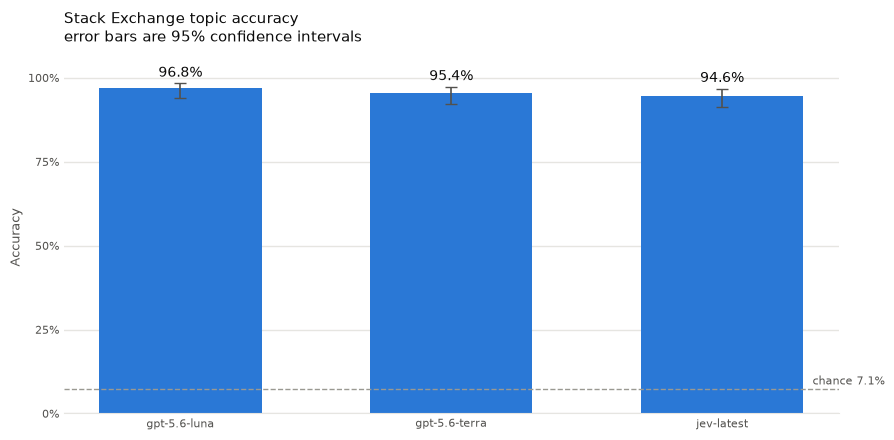

In [13]:
plot_df = scores[["model", "accuracy", "ci_low", "ci_high"]].copy()
plot_df["is_baseline"] = False

fig, ax = plt.subplots(figsize=(9, 4.5))

colors = ["#9a9992" if b else "#2a78d6" for b in plot_df["is_baseline"]]
errors = [plot_df["accuracy"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["accuracy"]]

ax.bar(
    plot_df["model"], plot_df["accuracy"], color=colors, width=0.6,
    yerr=errors, capsize=4, error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
)

# label above the error bar cap so the two do not overlap
for x, (value, high) in enumerate(zip(plot_df["accuracy"], plot_df["ci_high"])):
    ax.text(x, high + 0.02, f"{value:.1%}", ha="center", color="#0b0b0b", fontsize=10)

chance = 1 / len(LABELS)
ax.axhline(chance, color="#9a9992", linewidth=1, linestyle="--")
ax.text(len(plot_df) - 0.4, chance + 0.015, f"chance {chance:.1%}",
        ha="right", color="#52514e", fontsize=8)

ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e", labelsize=8, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#e6e5e1")
ax.set_title(
    "Stack Exchange topic accuracy\nerror bars are 95% confidence intervals",
    color="#0b0b0b", fontsize=11, loc="left", pad=14,
)
fig.tight_layout()
plt.show()

## 9. How fast is each API?

The accuracy run above is threaded and cached, so its wall-clock time says nothing about how
fast a single call is. To measure that we call the APIs directly - **bypassing the cache**, and
**one call at a time**, because eight concurrent workers measure throughput, not latency.

These are small samples over a network, so treat them as an order of magnitude rather than a
precise figure.

In [14]:
SPEED_SAMPLE = 20

speed_rows = []
for model_name, call in MODELS.items():
    latencies = []
    for record in tqdm(records[:SPEED_SAMPLE], desc=model_name):
        start = time.perf_counter()
        try:
            call(record["text"])  # deliberately uncached - we are timing the API itself
            latencies.append(time.perf_counter() - start)
        except Exception as error:
            print(f"  {model_name} failed: {str(error)[:100]}")

    if not latencies:
        continue

    latencies.sort()
    speed_rows.append(
        {
            "model": model_name,
            "calls": len(latencies),
            "mean_s": round(sum(latencies) / len(latencies), 2),
            "median_s": round(latencies[len(latencies) // 2], 2),
            "p90_s": round(latencies[int(len(latencies) * 0.9)], 2),
            "min_s": round(latencies[0], 2),
            "max_s": round(latencies[-1], 2),
        }
    )

speed = pd.DataFrame(speed_rows).sort_values("median_s").reset_index(drop=True)
speed

jev-latest:   0%|          | 0/20 [00:00<?, ?it/s]

jev-latest:   5%|▌         | 1/20 [00:00<00:10,  1.74it/s]

jev-latest:  10%|█         | 2/20 [00:01<00:10,  1.73it/s]

jev-latest:  15%|█▌        | 3/20 [00:01<00:10,  1.62it/s]

jev-latest:  20%|██        | 4/20 [00:02<00:10,  1.51it/s]

...

gpt-5.6-terra:  90%|█████████ | 18/20 [00:27<00:02,  1.46s/it]

gpt-5.6-terra:  95%|█████████▌| 19/20 [00:29<00:01,  1.33s/it]

gpt-5.6-terra: 100%|██████████| 20/20 [00:30<00:00,  1.26s/it]

gpt-5.6-terra: 100%|██████████| 20/20 [00:30<00:00,  1.51s/it]

,model,calls,mean_s,median_s,p90_s,min_s,max_s
0,jev-latest,20,0.68,0.67,0.78,0.57,1.10
1,gpt-5.6-terra,20,1.51,1.48,2.19,0.89,3.38
2,gpt-5.6-luna,20,1.63,1.57,2.69,1.07,2.93


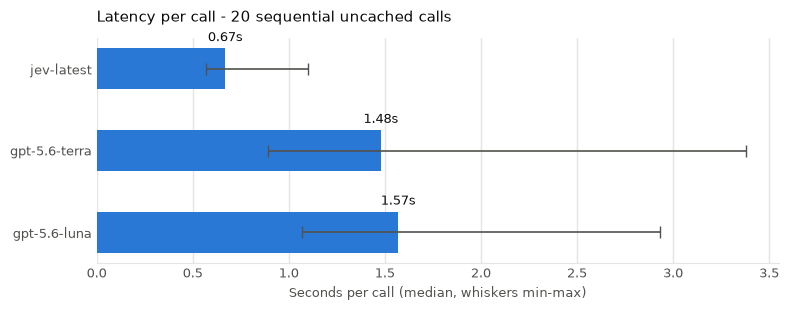

In [15]:
if not speed.empty:
    fig, ax = plt.subplots(figsize=(8, 3.2))

    y = range(len(speed))
    left = speed["median_s"] - speed["min_s"]
    right = speed["max_s"] - speed["median_s"]

    ax.barh(
        y, speed["median_s"], color="#2a78d6", height=0.5,
        xerr=[left, right], capsize=4,
        error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
    )

    for yi, value in zip(y, speed["median_s"]):
        ax.text(value, yi - 0.34, f"{value:.2f}s", ha="center", color="#0b0b0b", fontsize=9)

    ax.set_yticks(list(y))
    ax.set_yticklabels(speed["model"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Seconds per call (median, whiskers min-max)", color="#52514e", fontsize=9)
    ax.xaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.set_title(
        f"Latency per call - {SPEED_SAMPLE} sequential uncached calls",
        color="#0b0b0b", fontsize=11, loc="left", pad=12,
    )
    fig.tight_layout()
    plt.show()

## 10. Where the errors are

On 14 distinct topics there should be few errors - and the ones that exist are worth reading
one by one, because a post can honestly belong to two communities. That is label noise,
not a model mistake.

In [16]:
for model_name, answers in results.items():
    if not answers:
        continue
    mistakes = [a for a in answers if a["label"] != a["gold"]]
    print(f"\n=== {model_name}: {len(mistakes)} mistakes out of {len(answers)} ===")
    confusions = collections.Counter((a["gold"], a["label"]) for a in mistakes)
    for (gold, predicted), count in confusions.most_common(10):
        print(f"  {count}x  {gold}  ->  {predicted}")


=== jev-latest: 15 mistakes out of 280 ===
  5x  genai  ->  ai
  4x  datascience  ->  ai
  3x  ai  ->  datascience
  2x  travel  ->  politics
  1x  politics  ->  economics

=== gpt-5.6-luna: 9 mistakes out of 280 ===
  3x  ai  ->  datascience
  3x  genai  ->  ai
  2x  datascience  ->  ai
  1x  movies  ->  astronomy

=== gpt-5.6-terra: 13 mistakes out of 280 ===
  5x  genai  ->  ai
  4x  ai  ->  datascience
  3x  datascience  ->  ai
  1x  travel  ->  politics


## 11. Is the confidence worth anything?

This is the part you cannot do with a plain chat completion. If accuracy climbs with
confidence, you can route the low-confidence tail to a human and leave the rest alone - which
is usually the whole reason to run a classifier at all.

In [17]:
confident = [
    {**a, "model": name}
    for name, answers in results.items()
    for a in answers
    if a.get("confidence") is not None
]

if not confident:
    print("No model returned a confidence.")
else:
    frame = pd.DataFrame(confident)
    frame["correct"] = frame["label"] == frame["gold"]
    frame["bucket"] = pd.cut(
        frame["confidence"], [0, 0.5, 0.7, 0.9, 1.0], include_lowest=True,
        labels=["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"],
    )
    calibration = (
        frame.groupby(["model", "bucket"], observed=False)["correct"]
        .agg(["mean", "size"])
        .reset_index()
    )
    display(calibration)

,model,bucket,mean,size
0,jev-latest,<=0.5,0.750000,4
1,jev-latest,0.5-0.7,0.545455,22
2,jev-latest,0.7-0.9,0.888889,27
3,jev-latest,0.9-1.0,0.995595,227


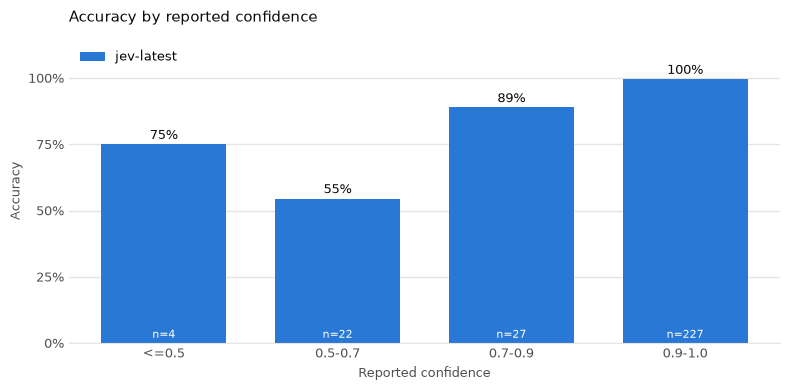

In [18]:
if confident:
    fig, ax = plt.subplots(figsize=(8, 4))
    buckets = ["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
    models = calibration["model"].unique()
    width = 0.8 / len(models)

    for i, model_name in enumerate(models):
        subset = calibration[calibration["model"] == model_name].set_index("bucket")
        subset = subset.reindex(buckets)
        positions = [b + i * width for b in range(len(buckets))]
        ax.bar(
            positions, subset["mean"].fillna(0), width=width * 0.9,
            color=["#2a78d6", "#eb6834", "#1baf7a"][i % 3], label=model_name,
        )
        for position, value, size in zip(positions, subset["mean"], subset["size"].fillna(0)):
            if size:
                ax.text(position, value + 0.02, f"{value:.0%}", ha="center",
                        color="#0b0b0b", fontsize=9)
                ax.text(position, 0.02, f"n={int(size)}", ha="center",
                        color="#ffffff", fontsize=8)

    ax.set_xticks([b + width * (len(models) - 1) / 2 for b in range(len(buckets))])
    ax.set_xticklabels(buckets)
    ax.set_xlabel("Reported confidence", color="#52514e", fontsize=9)
    ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=3)
    ax.set_title("Accuracy by reported confidence", color="#0b0b0b",
                 fontsize=11, loc="left", pad=12)
    fig.tight_layout()
    plt.show()

## 12. Save the per-row results

In [19]:
os.makedirs("results", exist_ok=True)

if results:
    flat = pd.DataFrame(
        [{**a, "model": name} for name, answers in results.items() for a in answers]
    )
    flat.to_csv(f"results/{DATASET}_predictions.csv", index=False)
    scores.to_csv(f"results/{DATASET}_summary.csv", index=False)
    print(f"wrote results/{DATASET}_predictions.csv ({len(flat)} rows)")

wrote results/stackexchange_predictions.csv (840 rows)


## Notes

- **A ceiling is a result.** If everything lands in the high 90s, this notebook has done its
  job: it says the task is saturated, not that the models are equal. Banking77 is where the
  separating signal lives.
- **Some "errors" are label noise.** A post in `ai` that is really about `datascience` is a
  disagreement with where it was filed, not a wrong answer. Read the confusion list before
  treating the last few points as model failure.
- **Token cost has a different shape per API.** Jev returns a probability over every option, so
  its output tokens scale with the size of the label set. OpenAI under an enum emits just the
  chosen label. Compare cost per correct answer, not raw token counts.
- **Only Jev returns a confidence.** That is the practical difference between the two APIs for
  this kind of task.
- **Latency and throughput are different questions.** The speed section times single sequential
  calls; the accuracy run uses eight workers, so its wall-clock time reflects concurrency, not
  per-call speed. Which one matters depends on whether you are classifying one item live or a
  million overnight.